# Exploratory Data Analysis (EDA)
## Rx Drug Marketing Mix Modeling (MMIX)

This notebook conducts exploratory analysis of a pharmaceutical marketing dataset to understand how marketing investments translate into sales outcomes.

### Business Objective
To evaluate how physician-targeted promotion (detailing) and consumer-directed advertising (DTCA) influence prescription drug sales across brands and therapeutic classes.

### Analytical Goals
- Understand distributions and scale of key variables
- Identify structural patterns in marketing investment
- Detect nonlinearities and diminishing returns
- Evaluate heterogeneity across classes and brands
- Assess panel structure and temporal dynamics
- Derive modeling implications for econometric and ML approaches

### Data Scope
- Time: 2013–2024
- Entities: 22 drug brands across 3 classes
- Variables:
    * Sales ($ Billions)
    * Detailing spend ($ Millions)
    * DTCA spend ($ Millions)

In [1]:
print("\n[EDA] Importing libraries...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("[EDA] Libraries loaded successfully.")


[EDA] Importing libraries...
[EDA] Libraries loaded successfully.


In [2]:
print("\n[EDA] Loading dataset...")

df = pd.read_excel("data/MMM_Drug_Data.xlsx")

df = df.rename(columns={
    "Class": "class",
    "Agent": "agent",
    "Year": "year",
    "Detailing": "detailing",
    "Direct-to-Consumer Advertising (DTCA)": "direct_to_consumer_ad",
    "Actual Sales": "actual_sales"
})

print("[EDA] Dataset loaded and columns standardized.")
display(df.head())


[EDA] Loading dataset...
[EDA] Dataset loaded and columns standardized.


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales
0,PPI,Prevacid,2013,43.880507,0.0,2.908294
1,PPI,Prilosec,2013,41.647961,0.0,14.723515
2,SSRI,Luvox,2013,22.366696,0.0,0.912018
3,SSRI,Paxil,2013,57.460824,0.0,11.267746
4,SSRI,Prozac,2013,84.533349,0.0,20.259977


In [3]:
print("\n[EDA] Generating business-readable summary statistics...")

summary = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].describe()

summary_readable = summary.copy()
summary_readable["actual_sales"] = summary["actual_sales"].apply(lambda x: f"${x:,.2f}B")
summary_readable["detailing"] = summary["detailing"].apply(lambda x: f"${x:,.2f}M")
summary_readable["direct_to_consumer_ad"] = summary["direct_to_consumer_ad"].apply(lambda x: f"${x:,.2f}M")

summary_readable = summary_readable.reset_index().rename(columns={"index": "Metric"})

display(summary_readable)

print("\n[Business Insight]")
print("Sales are highly concentrated, with a small number of blockbuster drugs driving the majority of revenue.")
print("Marketing investments exhibit wide dispersion, indicating heterogeneous strategies across brands.")


[EDA] Generating business-readable summary statistics...


,Metric,actual_sales,detailing,direct_to_consumer_ad
0,count,$207.00B,$207.00M,$207.00M
1,mean,$11.67B,$56.03M,$26.32M
2,std,$12.97B,$54.92M,$49.30M
3,min,$0.00B,$0.00M,$0.00M
4,25%,$0.99B,$3.86M,$0.00M
5,50%,$7.53B,$44.97M,$0.00M
6,75%,$19.61B,$85.12M,$39.36M
7,max,$63.22B,$243.33M,$240.35M



[Business Insight]
Sales are highly concentrated, with a small number of blockbuster drugs driving the majority of revenue.
Marketing investments exhibit wide dispersion, indicating heterogeneous strategies across brands.



[EDA] Visualizing raw distributions...


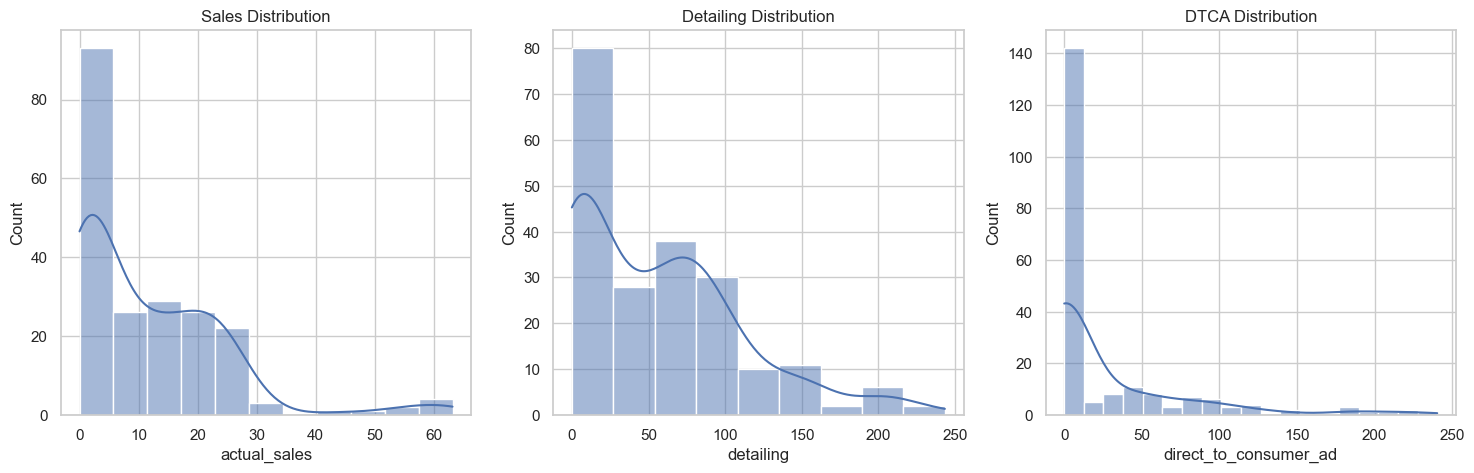


[Business Insight]
All variables exhibit strong right-skewness.
This reflects a typical 'blockbuster market' structure where few drugs dominate.


In [4]:
print("\n[EDA] Visualizing raw distributions...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0])
axes[0].set_title("Sales Distribution")

sns.histplot(df["detailing"], kde=True, ax=axes[1])
axes[1].set_title("Detailing Distribution")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2])
axes[2].set_title("DTCA Distribution")

plt.show()

print("\n[Business Insight]")
print("All variables exhibit strong right-skewness.")
print("This reflects a typical 'blockbuster market' structure where few drugs dominate.")

In [6]:
print("\n[EDA] Analyzing DTCA zero regime...")

zero_dtca = (df["direct_to_consumer_ad"] == 0).sum()
total = len(df)

print(f"Zero DTCA observations: {zero_dtca}")
print(f"Percentage: {zero_dtca/total:.2%}")

print("\n[Business Insight]")
print("Nearly half of observations have zero Direct-to-Consumer Advertising (DTCA).")
print("This suggests two distinct marketing regimes:")
print("1. Physician-driven (detailing-focused)")
print("2. Consumer-marketed (Direct-to-Consumer Advertising (DTCA) active)")


[EDA] Analyzing DTCA zero regime...
Zero DTCA observations: 98
Percentage: 47.34%

[Business Insight]
Nearly half of observations have zero Direct-to-Consumer Advertising (DTCA).
This suggests two distinct marketing regimes:
1. Physician-driven (detailing-focused)
2. Consumer-marketed (Direct-to-Consumer Advertising (DTCA) active)


In [7]:
print("\n[EDA] Evaluating panel structure (agent × year)...")

panel = pd.crosstab(df["agent"], df["year"])

expected = df["agent"].nunique() * df["year"].nunique()
actual = len(df)

print(f"Expected rows (balanced panel): {expected}")
print(f"Actual rows: {actual}")
print(f"Missing combinations: {expected - actual}")

display(panel)


[EDA] Evaluating panel structure (agent × year)...
Expected rows (balanced panel): 264
Actual rows: 207
Missing combinations: 57


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
agent,,,,,,,,,,,,
Aciphex,0,0,0,1,1,1,1,1,1,1,1,1
Altoprev,0,0,0,0,0,0,1,1,1,1,1,1
Celexa,0,0,1,1,1,1,1,1,1,1,1,1
Crestor,0,0,0,0,0,0,0,1,1,1,1,1
Lescol,1,1,1,1,1,1,1,1,1,1,1,1
Lescol XL,0,0,0,0,1,1,1,1,1,1,1,1
Lexapro,0,0,0,0,0,0,1,1,1,1,1,1
Lipitor,0,1,1,1,1,1,1,1,1,1,1,1
Luvox,1,1,1,1,1,1,1,1,1,1,1,1


## Log Transformation

In [8]:
print("\n[EDA] Applying log transformations...")

df["log_sales"] = np.log1p(df["actual_sales"])
df["log_detailing"] = np.log1p(df["detailing"])
df["log_dtca"] = np.log1p(df["direct_to_consumer_ad"])

df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

print("[EDA] Transformation complete.")


[EDA] Applying log transformations...
[EDA] Transformation complete.



[EDA] Comparing raw vs log distributions...


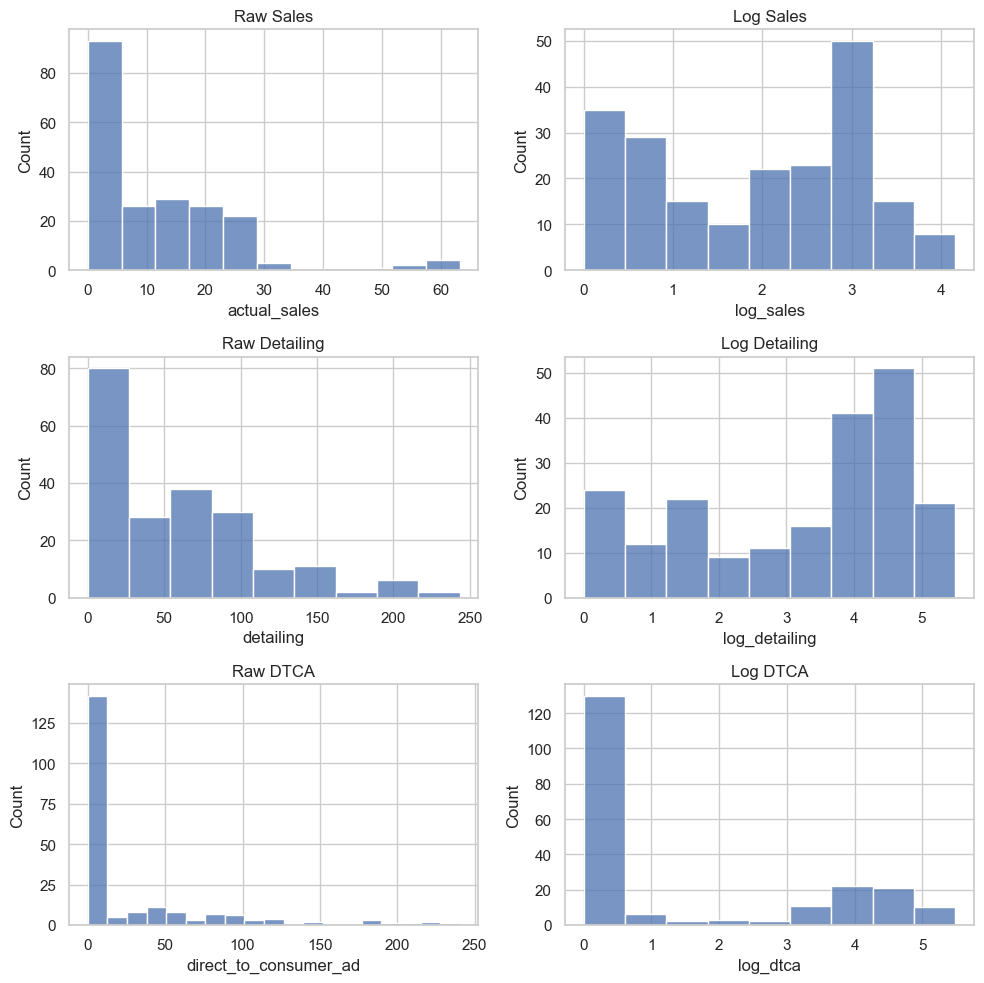


[Business Insight]
Log transformation reduces skewness and stabilizes variance.
This aligns with economic intuition: marketing effects are multiplicative, not linear.


In [9]:
print("\n[EDA] Comparing raw vs log distributions...")

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

sns.histplot(df["actual_sales"], ax=axes[0,0]); axes[0,0].set_title("Raw Sales")
sns.histplot(df["log_sales"], ax=axes[0,1]); axes[0,1].set_title("Log Sales")

sns.histplot(df["detailing"], ax=axes[1,0]); axes[1,0].set_title("Raw Detailing")
sns.histplot(df["log_detailing"], ax=axes[1,1]); axes[1,1].set_title("Log Detailing")

sns.histplot(df["direct_to_consumer_ad"], ax=axes[2,0]); axes[2,0].set_title("Raw DTCA")
sns.histplot(df["log_dtca"], ax=axes[2,1]); axes[2,1].set_title("Log DTCA")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("Log transformation reduces skewness and stabilizes variance.")
print("This aligns with economic intuition: marketing effects are multiplicative, not linear.")


[EDA] Testing for diminishing returns...


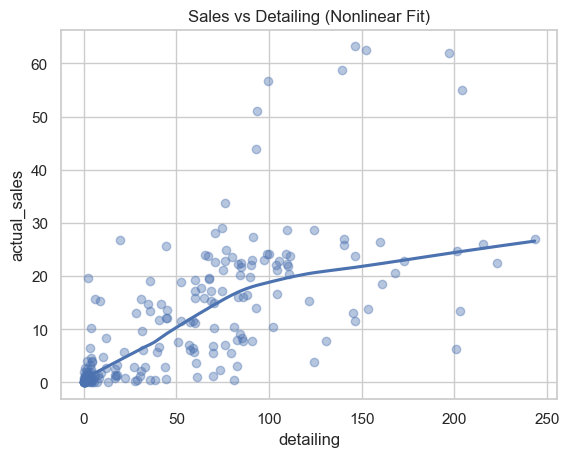


[Business Insight]
The curve flattens at higher detailing levels, indicating diminishing marginal returns.
Incremental spend becomes less effective at scale.


In [10]:
print("\n[EDA] Testing for diminishing returns...")

sns.regplot(
    data=df,
    x="detailing",
    y="actual_sales",
    lowess=True,
    scatter_kws={"alpha":0.4}
)

plt.title("Sales vs Detailing (Nonlinear Fit)")
plt.show()

print("\n[Business Insight]")
print("The curve flattens at higher detailing levels, indicating diminishing marginal returns.")
print("Incremental spend becomes less effective at scale.")


[EDA] Evaluating log-log relationships...


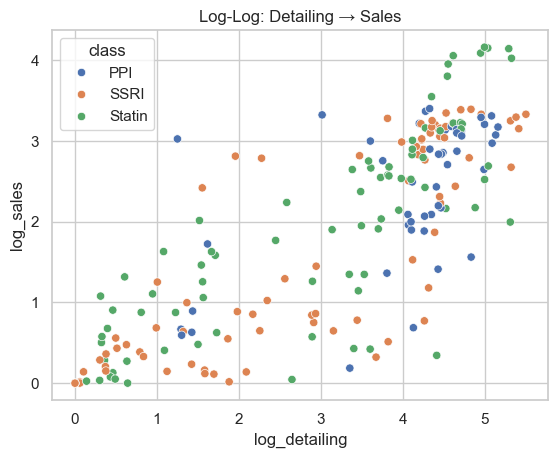

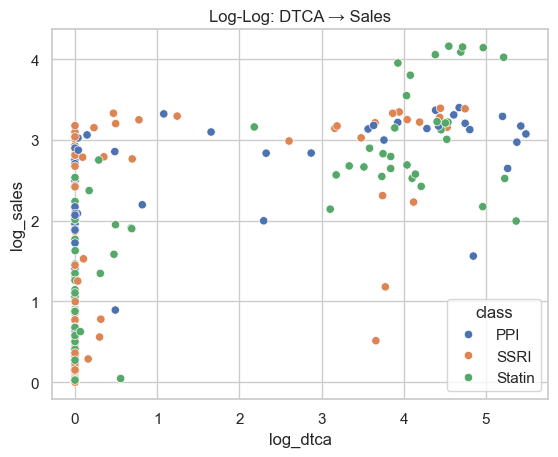


[Business Insight]
Relationships become linear in log space.
This supports elasticity-based modeling.


In [11]:
print("\n[EDA] Evaluating log-log relationships...")

sns.scatterplot(x=df["log_detailing"], y=df["log_sales"], hue=df["class"])
plt.title("Log-Log: Detailing → Sales")
plt.show()

sns.scatterplot(x=df["log_dtca"], y=df["log_sales"], hue=df["class"])
plt.title("Log-Log: DTCA → Sales")
plt.show()

print("\n[Business Insight]")
print("Relationships become linear in log space.")
print("This supports elasticity-based modeling.")


[EDA] Comparing class-level sensitivities...


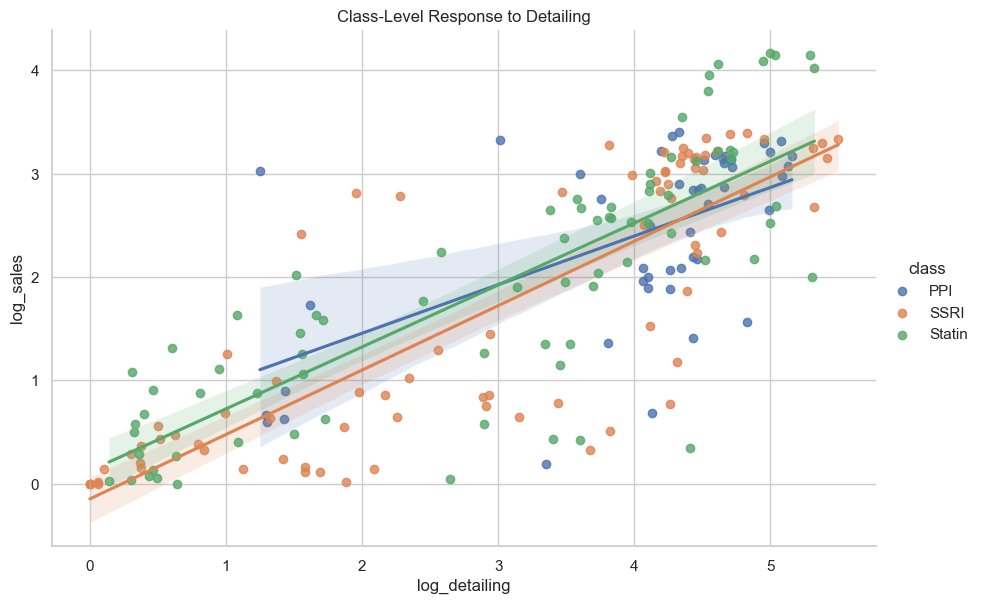


[Business Insight]
Different slopes indicate that marketing effectiveness varies by class.
This justifies class interaction terms in modeling.


In [12]:
print("\n[EDA] Comparing class-level sensitivities...")

sns.lmplot(
    data=df,
    x="log_detailing",
    y="log_sales",
    hue="class",
    height=6,
    aspect=1.5
)

plt.title("Class-Level Response to Detailing")
plt.show()

print("\n[Business Insight]")
print("Different slopes indicate that marketing effectiveness varies by class.")
print("This justifies class interaction terms in modeling.")


[EDA] Analyzing temporal trends...


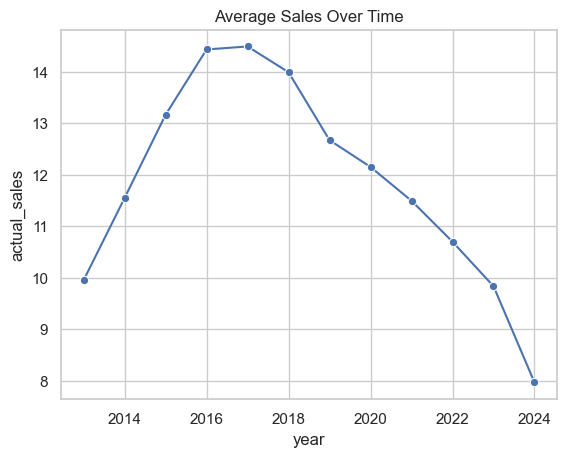


[Business Insight]
Sales trends reflect lifecycle dynamics and market maturity.


In [13]:
print("\n[EDA] Analyzing temporal trends...")

yearly = df.groupby("year")[["actual_sales","detailing","direct_to_consumer_ad"]].mean().reset_index()

sns.lineplot(data=yearly, x="year", y="actual_sales", marker="o")
plt.title("Average Sales Over Time")
plt.show()

print("\n[Business Insight]")
print("Sales trends reflect lifecycle dynamics and market maturity.")


[EDA] Correlation analysis...


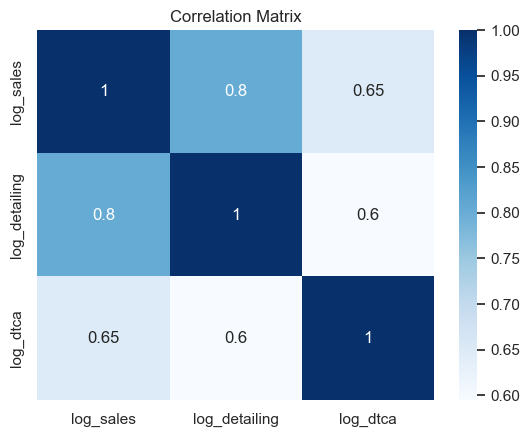


[Business Insight]
Moderate correlation exists between marketing channels.
Multicollinearity risk should be monitored in regression models.


In [14]:
print("\n[EDA] Correlation analysis...")

corr = df[["log_sales","log_detailing","log_dtca"]].corr()

sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

print("\n[Business Insight]")
print("Moderate correlation exists between marketing channels.")
print("Multicollinearity risk should be monitored in regression models.")

## EDA Takeaways (Business + Modeling)

### Market Structure
- Sales are highly skewed, driven by a few dominant drugs
- Marketing spend varies significantly across brands

### Marketing Effectiveness
- Strong positive relationship between detailing and sales
- DTCA impact is more heterogeneous and regime-dependent

### Nonlinearity
- Clear evidence of diminishing returns
- Log-log transformation provides linear structure

### Heterogeneity
- Classes exhibit different baseline sales levels
- Sensitivity to marketing varies across classes

### Panel Dynamics
- Data is unbalanced panel
- Within-agent trends confirm marketing-sales linkage

### Modeling Implications
- Use log-log specification
- Include class and agent effects
- Include DTCA zero indicator
- Monitor multicollinearity

### Proposed Model

log(Sales) ~ log(Detailing) + log(DTCA) + Class + Agent + Year